In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
stock_data = yf.download('AAPL', start='2024-01-01' )
stock_data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-01-02,183.731293,186.502507,181.999286,185.225762,82488700
2024-01-03,182.355591,183.968836,181.544015,182.325900,58414500
2024-01-04,180.039673,181.207533,179.020264,180.277196,71983600
2024-01-05,179.317139,180.880895,178.317529,180.118823,62379700
2024-01-08,183.652115,183.691712,179.633861,180.217791,59144500


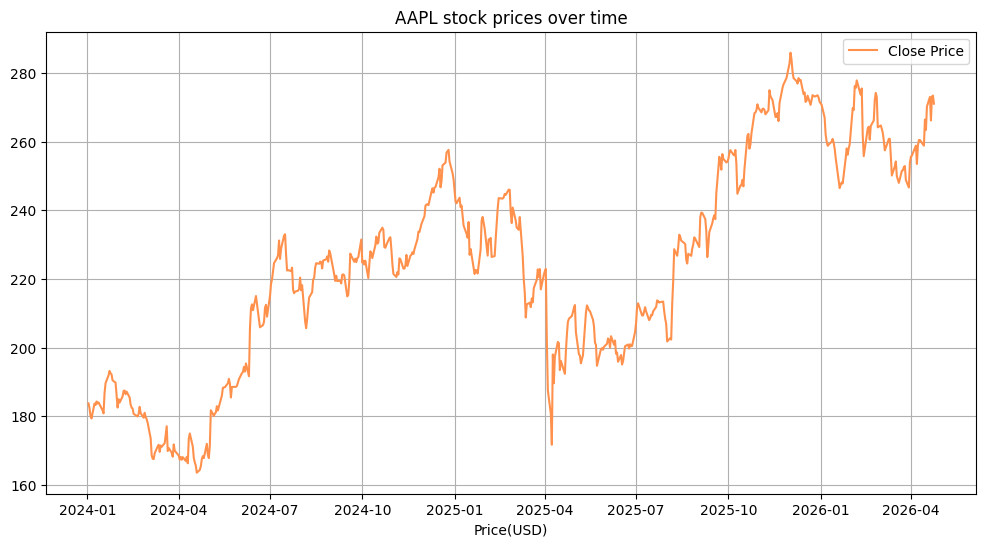

In [3]:
plt.figure(figsize=(12,6))
plt.plot(stock_data.index, stock_data['Close'], label='Close Price', color='#FF914D')
plt.title("AAPL stock prices over time")
plt.xlabel("Date")
plt.xlabel("Price(USD)")
plt.legend()
plt.grid(True)
plt.show()

## Classical TIme Series Decomposition

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition_additve = seasonal_decompose(stock_data['Close'], model='additive', period=30)

trend_additive = decomposition_additve.trend
seasonal_additive = decomposition_additve.seasonal
residual_additive = decomposition_additve.resid

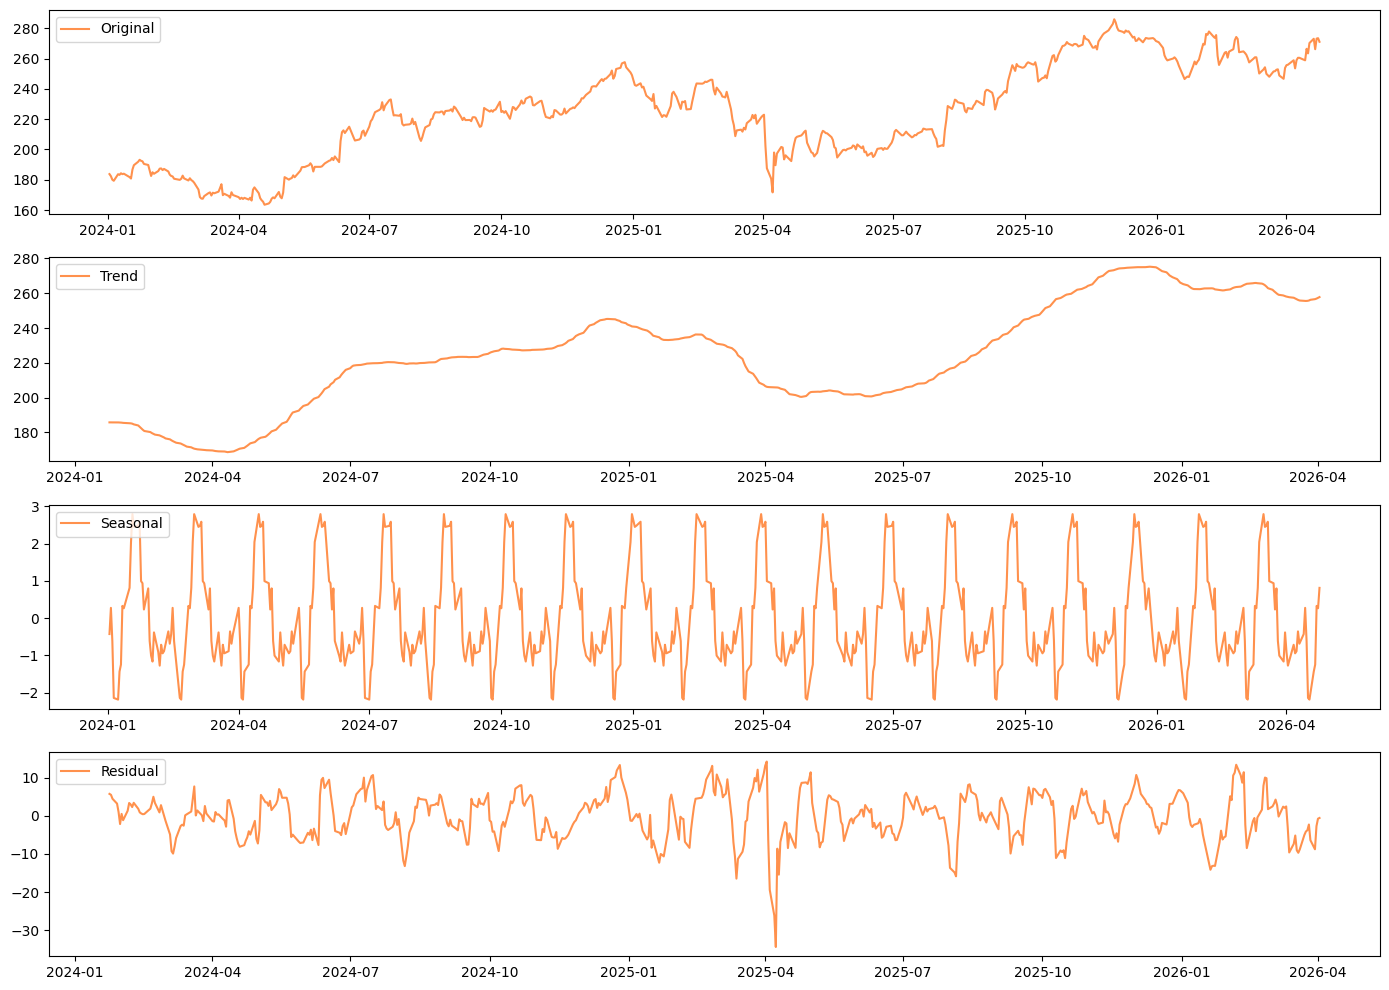

In [5]:
plt.figure(figsize=(14,10))

plt.subplot(411)
plt.plot(stock_data['Close'], label='Original', color='#FF914D')
plt.legend(loc='upper left')

plt.subplot(412)
plt.plot(trend_additive, label='Trend', color='#FF914D')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(seasonal_additive, label='Seasonal', color='#FF914D')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(residual_additive, label='Residual', color='#FF914D')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

## STL Decomposition

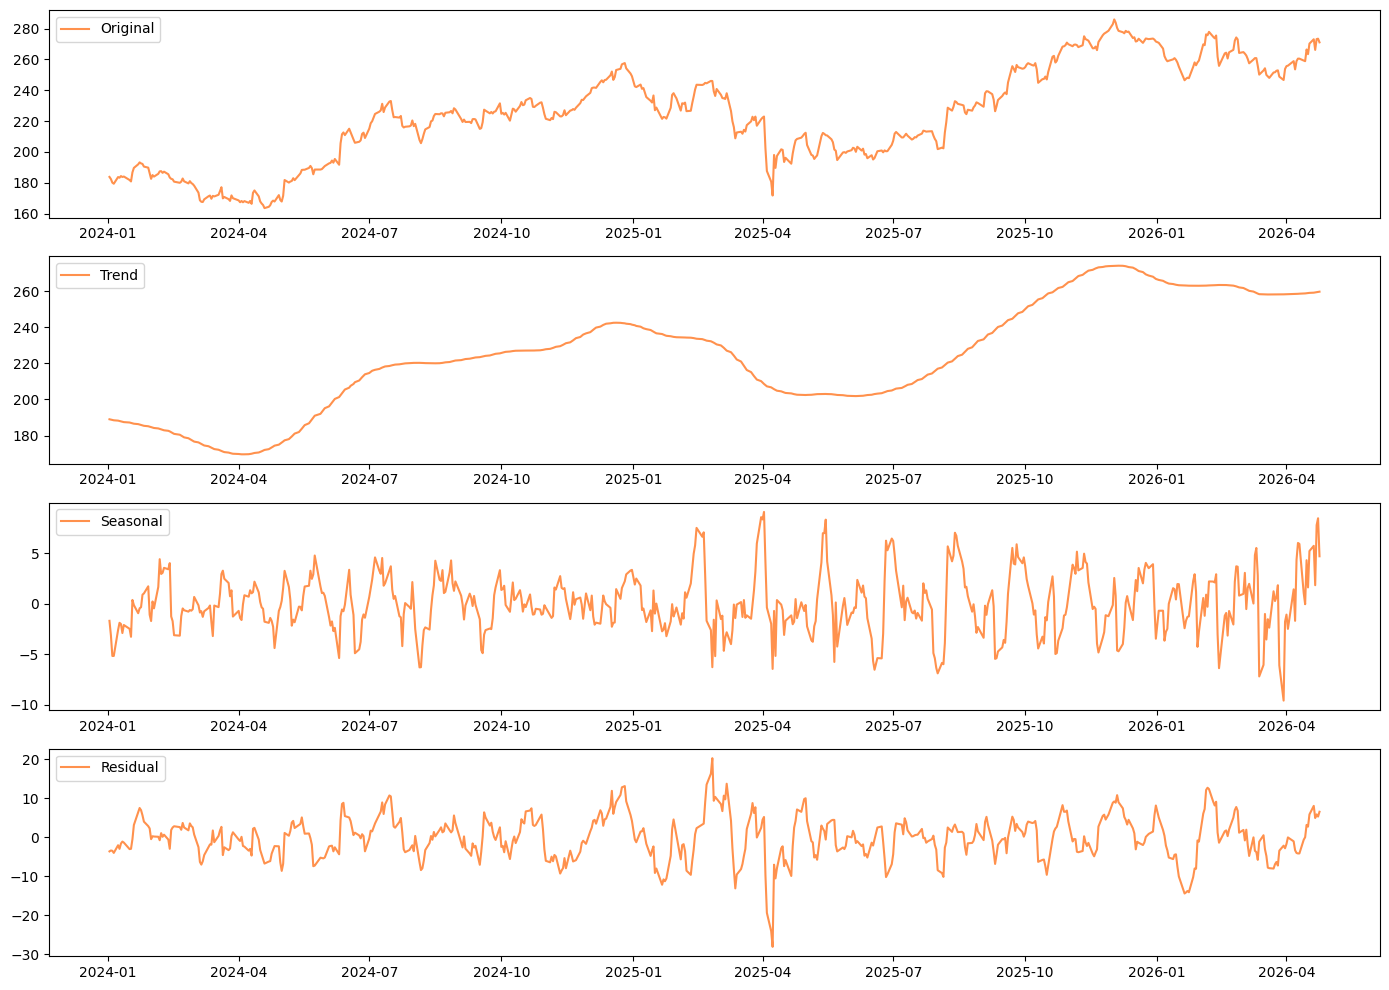

In [6]:
from statsmodels.tsa.seasonal import STL

# Perform STL decomposition
stl = STL(stock_data['Close'], period=30)
result = stl.fit()

# Plot Decomposition components
plt.figure(figsize=(14,10))

plt.subplot(411)
plt.plot(result.observed, label='Original', color='#FF914D')
plt.legend(loc='upper left')

plt.subplot(412)
plt.plot(result.trend, label='Trend', color='#FF914D')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(result.seasonal, label='Seasonal', color='#FF914D')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(result.resid, label='Residual', color='#FF914D')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

## Stationarity Test

In [7]:
from statsmodels.tsa.stattools import adfuller

# Performing the Augmented Dickey-Fuller Test
adf_test = adfuller(stock_data['Close'])
print("ADF Test Results")
print(f"ADF stats : {round(adf_test[0],3)}")
print(f"p-value : {round(adf_test[1],3)}")
print("Critical Value")

for key, value in adf_test[4].items():
    print(f'    {key} : {round(value,3)}')

ADF Test Results
ADF stats : -1.48
p-value : 0.544
Critical Value
    1% : -3.442
    5% : -2.867
    10% : -2.569


In [8]:
from statsmodels.tsa.stattools import kpss

# Performing the KPSS Test
kpss_test = kpss(stock_data['Close'], regression='ct')       # 'c' for constant  (level stationarity), 'ct' for trend
print("KPSS Test Results")
print(f"KPSS stats : {round(kpss_test[0],2)}")
print(f"p-value : {kpss_test[1]}")
print("Critical Value")

for key, value in kpss_test[3].items():
    print(f'    {key} : {round(value,3)}')

KPSS Test Results
KPSS stats : 0.23
p-value : 0.01
Critical Value
    10% : 0.119
    5% : 0.146
    2.5% : 0.176
    1% : 0.216


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23680\3729291994.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = kpss(stock_data['Close'], regression='ct')       # 'c' for constant  (level stationarity), 'ct' for trend


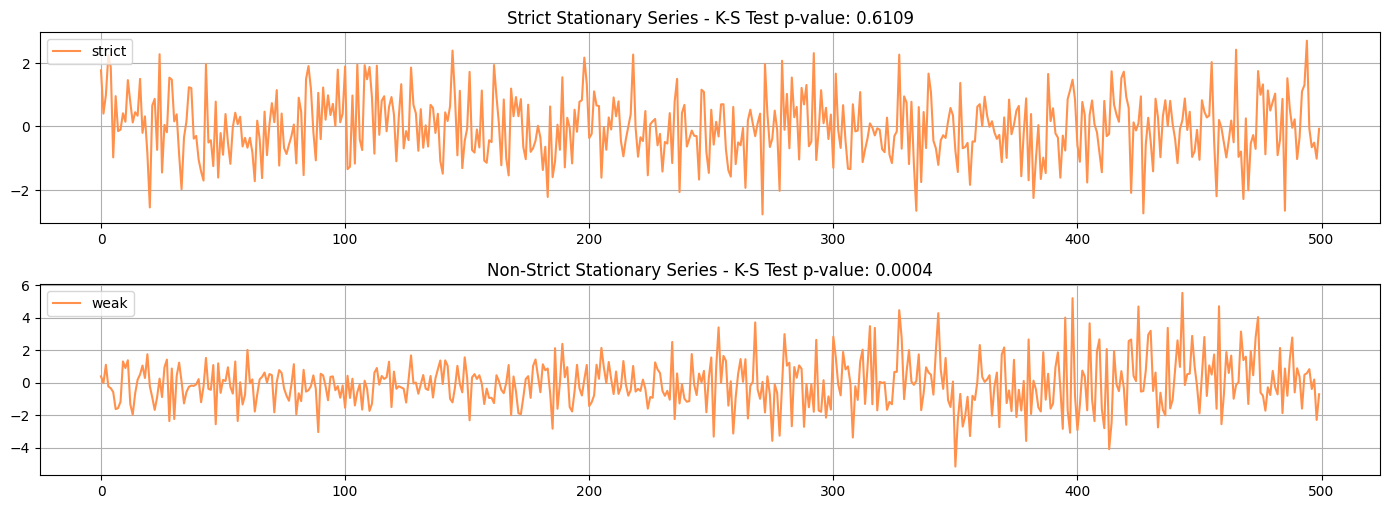

Strict Stationary Series - K-S Test Statistic: 0.068, p-value: 0.6109
Weak Stationary Series - K-S Test Statistic: 0.184, p-value: 0.0004


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

# Generating synthetic data for demonstration
np.random.seed(0)
n = 500

# Strictly stationary series : normally distributed random noise
strict_stationary_series = np.random.normal(0, 1, n)

# Non-Strictly stationary series : changing variance
non_strict_stationary_series = np.concatenate([np.random.normal(0, 1, n//2),          
    np.random.normal(0, 2, n//2)
])

# Funtion to split series into two halves and perform K-5 test
def ks_test_stationarity(series):
    split = len(series) // 2
    series_first_half = series[:split]
    series_second_half = series[split:]
    stat, p_value = ks_2samp(series_first_half, series_second_half)
    return stat, p_value

# Perform the K-5 test om strictly stationarity series
ks_stat_strict, ks_p_value_strict = ks_test_stationarity(strict_stationary_series)

# Perform the K-5 test om non-strict stationarity series
ks_stat_non_strict, ks_p_value_non_strict = ks_test_stationarity(non_strict_stationary_series)

# Plotting the series
plt.figure(figsize=(14,10))
plt.subplot(411)
plt.plot(strict_stationary_series, label='strict', color='#FF914D')
plt.title(f"Strict Stationary Series - K-S Test p-value: {round(ks_p_value_strict, 4)}")
plt.legend(loc='upper left')
plt.grid(True)

plt.subplot(412)
plt.plot(non_strict_stationary_series, label='weak', color='#FF914D')
plt.title(f"Non-Strict Stationary Series - K-S Test p-value: {round(ks_p_value_non_strict, 4)}")
plt.legend(loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()
print(f"Strict Stationary Series - K-S Test Statistic: {round(ks_stat_strict, 4)}, p-value: {round(ks_p_value_strict, 4)}\n\
Weak Stationary Series - K-S Test Statistic: {round(ks_stat_non_strict, 4)}, p-value: {round(ks_p_value_non_strict, 4)}")

## Making Non-Stationary Data Stationary

In [10]:
# Performing ADS and KPSS Test
def adf_test(series):
    result = adfuller(series)
    print("ADF stats:", result[0])
    print("p-Value:", result[1])
    for key, value in result[4].items():
        print(f"Critical Value ({key}): {value:.3f}")
def kpss_test(series):
    result = kpss(series, regression='c')
    print("KPSS stats:", result[0])
    print("p-Value:", result[1])
    for key, value in result[3].items():
        print(f"Critical Value ({key}): {value:.3f}")

In [11]:
prices = stock_data['Close'].squeeze()

In [12]:
print(type(prices))
print(prices.shape)

<class 'pandas.core.series.Series'>
(580,)


In [13]:
adf_test(prices)

ADF stats: -1.479730267515605
p-Value: 0.5435135983611747
Critical Value (1%): -3.442
Critical Value (5%): -2.867
Critical Value (10%): -2.569


In [14]:
kpss_test(prices)

KPSS stats: 2.2052722028061273
p-Value: 0.01
Critical Value (10%): 0.347
Critical Value (5%): 0.463
Critical Value (2.5%): 0.574
Critical Value (1%): 0.739


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23680\2100936390.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series, regression='c')


In [15]:
prices.head()

Date
2024-01-02    183.731293
2024-01-03    182.355591
2024-01-04    180.039673
2024-01-05    179.317139
2024-01-08    183.652115
Name: AAPL, dtype: float64

In [16]:
# First order differencing
prices_diff = prices.diff()

In [17]:
# Second order differencing
prices.diff().diff().head()

Date
2024-01-02         NaN
2024-01-03         NaN
2024-01-04   -0.940216
2024-01-05    1.593384
2024-01-08    5.057510
Name: AAPL, dtype: float64

In [18]:
import numpy as np
from scipy import stats 

In [19]:
# Log Transformation
prices_log = np.log(prices)

# Square Root Transformation
prices_sqrt = np.sqrt(prices)

# Box-cox Transformation
# Note: Box_Cox requires all postive values
prices_boxcox, lam = stats.boxcox(prices[prices > 0])

In [20]:
adf_test(prices_sqrt)
adf_test(prices_log)
adf_test(prices_boxcox)
adf_test(prices_diff.dropna())

ADF stats: -1.3958740690176654
p-Value: 0.5842525354557423
Critical Value (1%): -3.442
Critical Value (5%): -2.867
Critical Value (10%): -2.569
ADF stats: -1.597267984814401
p-Value: 0.484965720614452
Critical Value (1%): -3.442
Critical Value (5%): -2.867
Critical Value (10%): -2.569
ADF stats: -1.4734867826814286
p-Value: 0.5465839158583917
Critical Value (1%): -3.442
Critical Value (5%): -2.867
Critical Value (10%): -2.569
ADF stats: -22.560380213704484
p-Value: 0.0
Critical Value (1%): -3.442
Critical Value (5%): -2.867
Critical Value (10%): -2.569


## Here as you can see that transformation didn't work for this data as it is also clear since data doesnt 'Spread' (Variance) much, the problem was mainly inconsistent mean

In [21]:

from scipy import signal
# Using a linear trend
trend = np.polyfit(np.arange(len(prices)), prices, 1)
trendline = np.polyval(trend, np.arange(len(prices)))
prices_detrended = prices - trendline

In [22]:
adf_test(prices_detrended)

ADF stats: -2.515366148736985
p-Value: 0.1117801994906717
Critical Value (1%): -3.442
Critical Value (5%): -2.867
Critical Value (10%): -2.569


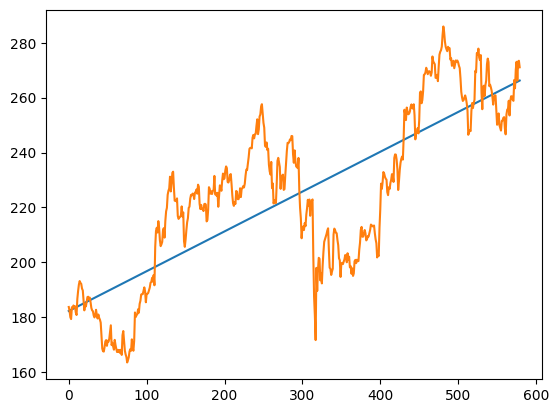

In [23]:
plt.plot(np.arange(len(prices)), trendline)
plt.plot(np.arange(len(prices)), prices)
plt.show()

In [24]:
# Using moving average to remove trend
window = 12   #Example window size
prices_ma = prices.rolling(window=window).mean()
prices_detrended = prices - prices_ma
prices_detrended = prices_detrended.dropna()

In [25]:
adf_test(prices_detrended)

ADF stats: -7.9665794177491485
p-Value: 2.8542894654574333e-12
Critical Value (1%): -3.442
Critical Value (5%): -2.867
Critical Value (10%): -2.569


In [26]:
3.424383558209901e-12 < 0.05

True

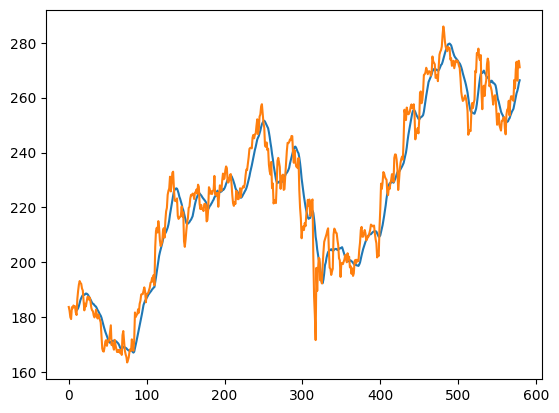

In [27]:
plt.plot(np.arange(len(prices)), prices_ma)
plt.plot(np.arange(len(prices)), prices)
plt.show()

In [28]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Seasonal decompose using moving averages
decomposition = seasonal_decompose(prices, model='additive', period=30)
prices_adjusted = prices/decomposition.seasonal
prices_adjusted = prices_adjusted.dropna()

In [29]:
adf_test(prices_adjusted)

ADF stats: -16.275503884213478
p-Value: 3.4537058484978165e-29
Critical Value (1%): -3.442
Critical Value (5%): -2.867
Critical Value (10%): -2.570


### White Noise and Random Walk

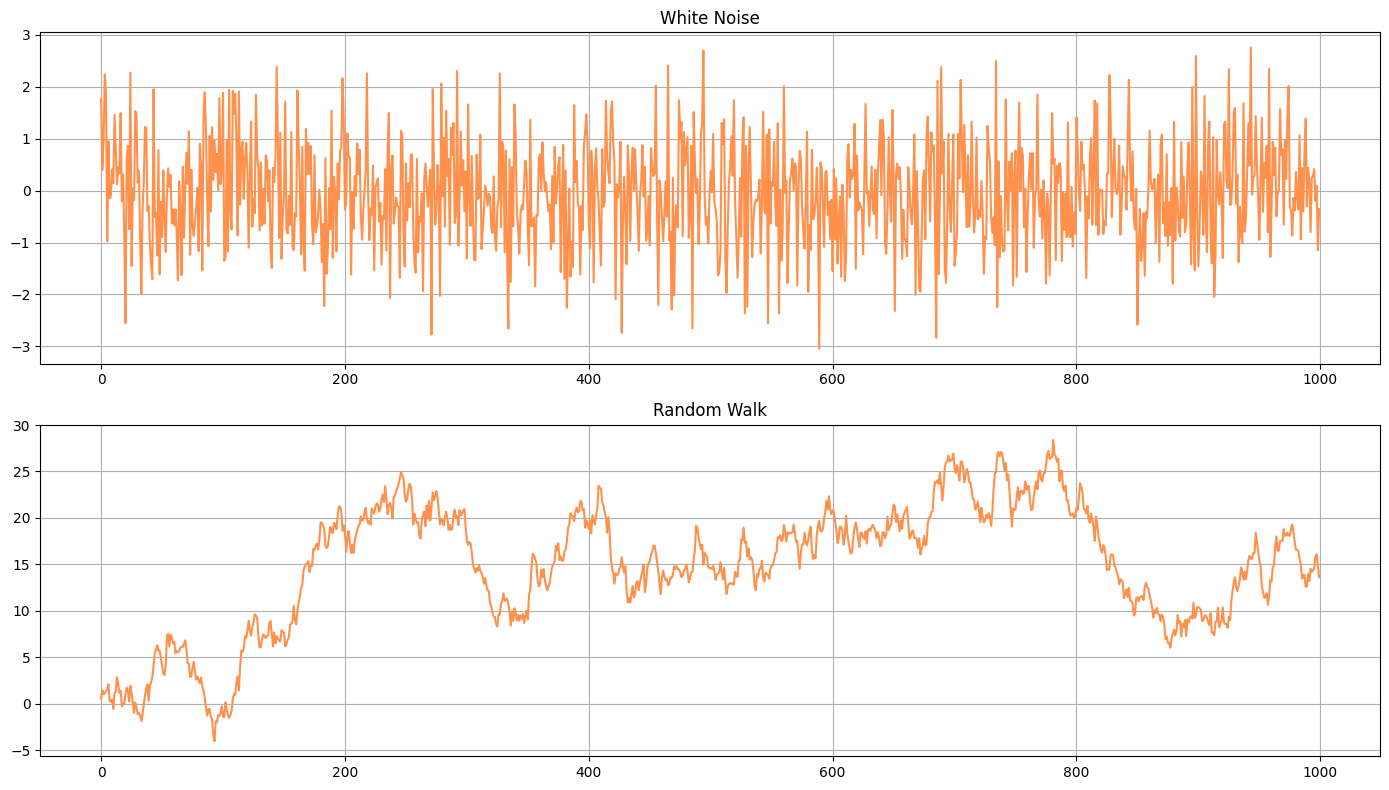


 Ljung Box for White Noise:
      lb_stat  lb_pvalue
10  14.025574   0.171828

 Ljung Box for Random Walk :
        lb_stat  lb_pvalue
10  8828.660312        0.0


In [30]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox

# Generating White noise and Random Walk for comparision
np.random.seed(0)
n = 1000

# White Noise
white_noise = np.random.normal(0, 1, n)

# Random Noise
random_shock = np.random.normal(0, 1, n)
random_walk = np.cumsum(random_shock)

# Plotting the series
plt.figure(figsize=(14,8))

plt.subplot(2, 1, 1)
plt.plot(white_noise, color = '#FF914D')
plt.title("White Noise")
plt.grid(True)
plt.subplot(2, 1, 2)
plt.plot(random_walk, color = '#FF914D')
plt.title("Random Walk")

plt.tight_layout()
plt.grid(True)
plt.show()

# Ljumg Box Test
print("\n Ljung Box for White Noise:")
lb_test_white_noise = acorr_ljungbox(white_noise, lags=[10], return_df=True)
print(lb_test_white_noise)

print("\n Ljung Box for Random Walk :")
lb_test_random_walk = acorr_ljungbox(random_walk, lags=[10], return_df=True)
print(lb_test_random_walk)

## Time Series Forecasting Model

### Auto Regressive Model

In [31]:
stock = yf.download('AAPL', start='2023-01-01')

apple_price_stationary = stock['Close'].diff().dropna()

# Splitting the data into test train split
train_data, test_data = apple_price_stationary[:-30], apple_price_stationary[-30:]

[*********************100%***********************]  1 of 1 completed


In [32]:
apple_price_stationary 

Ticker,AAPL
Date,
2023-01-04,1.269638
2023-01-05,-1.318871
2023-01-06,4.527412
2023-01-09,0.521652
2023-01-10,0.570847
...,...
2026-04-20,2.819977
2026-04-21,-6.879974
2026-04-22,7.000000


In [33]:
stock

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2023-01-03,123.096024,128.834003,122.210227,128.223793,112117500
2023-01-04,124.365662,126.629364,123.105865,124.887295,89113600
2023-01-05,123.046791,125.753387,122.790900,125.123489,80962700
2023-01-06,127.574203,128.233627,122.918861,124.021187,87754700
2023-01-09,128.095856,131.304413,127.839965,128.410812,70790800
...,...,...,...,...,...
2026-04-20,273.049988,274.279999,270.290009,270.329987,36590200
2026-04-21,266.170013,272.799988,265.399994,271.500000,50209800


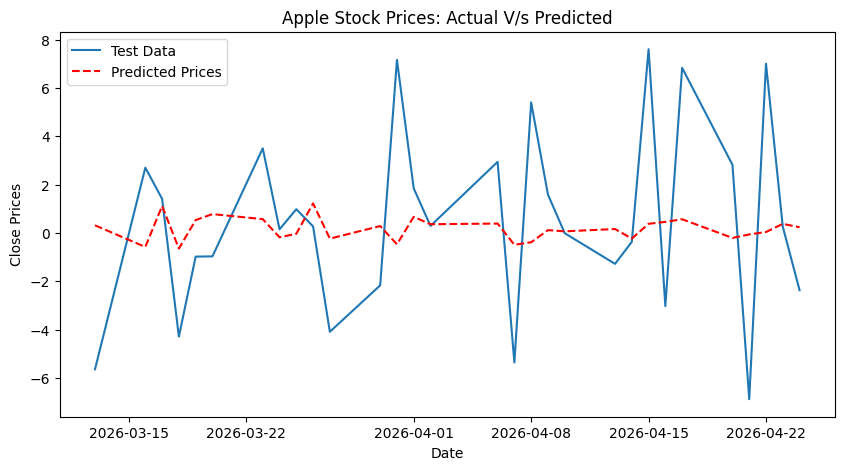

RMSE :  3.82


In [34]:
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Fill the AR Model to Training Data
model = AutoReg(train_data, lags=30)
model_fit = model.fit()

# Make predictions on the test data
predictions = model_fit.predict(
    start = len(train_data),
    end = len(train_data) + len(test_data)-1,
    dynamic=False
)

# Plotting the Actual V/S Predicted Values 
plt.figure(figsize=(10,5))
plt.plot(test_data.index, test_data, label="Test Data" )
plt.plot(test_data.index, predictions, linestyle='--', label="Predicted Prices", color='red')
plt.title('Apple Stock Prices: Actual V/s Predicted')
plt.xlabel('Date')
plt.ylabel('Close Prices')
plt.legend()
plt.show()

# Evaluating model using RMSE score
rmse = round(np.sqrt(mean_squared_error(test_data, predictions)), 2)
print("RMSE : ", rmse)

### Moving Avg. Model

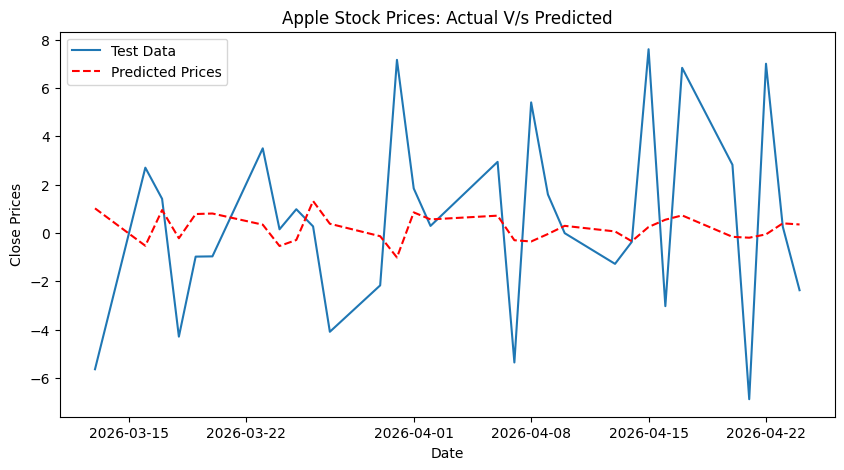

RMSE :  3.94


In [35]:
from statsmodels.tsa.arima.model import ARIMA 

# Fit the MA model to the training set
model = ARIMA(train_data, order=(0, 0, 30))
model_fit = model.fit()

# Make predictions on the test data
predictions = model_fit.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data) - 1,
    dynamic=False
)

# Plotting Actual V/S Predicted Values
plt.figure(figsize=(10,5))
plt.plot(test_data.index, test_data, label="Test Data" )
plt.plot(test_data.index, predictions, linestyle='--', label="Predicted Prices", color='red')
plt.title('Apple Stock Prices: Actual V/s Predicted')
plt.xlabel('Date')
plt.ylabel('Close Prices')
plt.legend()
plt.show()

# Evaluating model using RMSE score
rmse = round(np.sqrt(mean_squared_error(test_data, predictions)), 2)
print("RMSE : ", rmse)

### ARMA Model

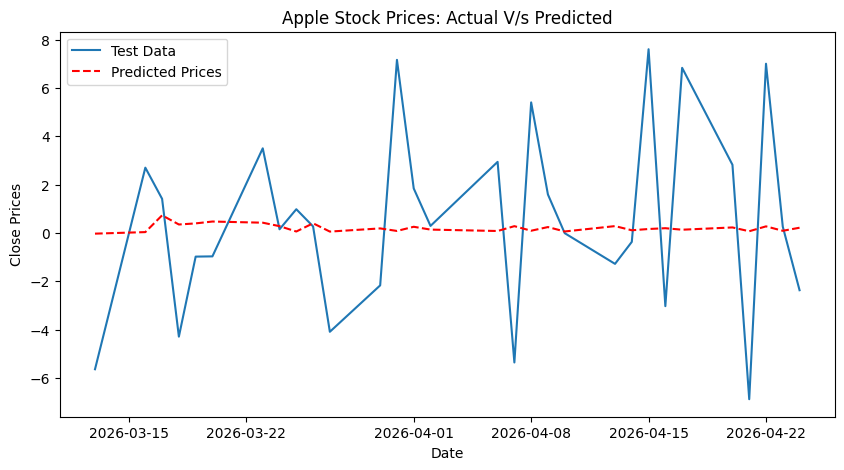

RMSE :  3.83


In [36]:
model = ARIMA(train_data, order=(7, 0, 7))     # the best order for the model is decided by ACF or PACF
model_fit = model.fit()

predictions = model_fit.predict(
    start = len(train_data),
    end = len(train_data) + len(test_data) -1,
    dynamic=False
)

# Plotting Actual V/S Predicted Values
plt.figure(figsize=(10,5))
plt.plot(test_data.index, test_data, label="Test Data" )
plt.plot(test_data.index, predictions, linestyle='--', label="Predicted Prices", color='red')
plt.title('Apple Stock Prices: Actual V/s Predicted')
plt.xlabel('Date')
plt.ylabel('Close Prices')
plt.legend()
plt.show()

# Evaluating model using RMSE score
rmse = round(np.sqrt(mean_squared_error(test_data, predictions)), 2)
print("RMSE : ", rmse)    

### ARIMA model

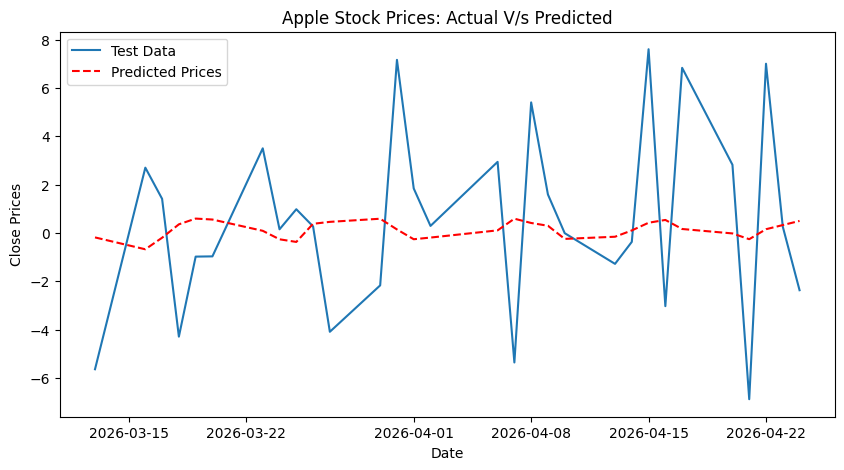

RMSE :  3.89


In [37]:
model = ARIMA(train_data, order=(7, 1, 7))     # the best order for the model is decided by ACF or PACF
model_fit = model.fit()

predictions = model_fit.predict(
    start = len(train_data),
    end = len(train_data) + len(test_data) -1,
    dynamic=False
)

# Plotting Actual V/S Predicted Values
plt.figure(figsize=(10,5))
plt.plot(test_data.index, test_data, label="Test Data" )
plt.plot(test_data.index, predictions, linestyle='--', label="Predicted Prices", color='red')
plt.title('Apple Stock Prices: Actual V/s Predicted')
plt.xlabel('Date')
plt.ylabel('Close Prices')
plt.legend()
plt.show()

# Evaluating model using RMSE score
rmse = round(np.sqrt(mean_squared_error(test_data, predictions)), 2)
print("RMSE : ", rmse)    

In [38]:
# from statsmodels.tsa.statespace.sarimax import SARIMAX

# p, d, q = 7, 1, 7
# P, D, Q, s = 1, 1, 1, 45  

# # the seasonality (s) is taken 45 as its seen earlier in Time Series Decomposition section the cycle is repeating every 45 days 

# # Fit the MA model to the training set
# model = SARIMAX(train_data, order=(p, d, q), seasonal_order=(P, D, Q, s))
# model_fit = model.fit()

# # Make predictions on the test data
# predictions = model_fit.predict(
#     start=len(train_data),
#     end=len(train_data) + len(test_data) - 1,
#     dynamic=False
# )

# # Plotting Actual V/S Predicted Values
# plt.figure(figsize=(10,5))
# plt.plot(test_data.index, test_data, label="Test Data" )
# plt.plot(test_data.index, predictions, linestyle='--', label="Predicted Prices", color='red')
# plt.title('Apple Stock Prices: Actual V/s Predicted')
# plt.xlabel('Date')
# plt.ylabel('Close Prices')
# plt.legend()
# plt.show()

# # Evaluating model using RMSE score
# rmse = round(np.sqrt(mean_squared_error(test_data, predictions)), 2)
# print("RMSE : ", rmse)

## Vector Models

In [39]:
stock = yf.download('AAPL', start='2023-01-01', end='2024-09-18')
tsla = yf.download('TSLA', start='2023-01-01', end='2024-09-18')
stock['TSLA_Close'] = tsla['Close']
apple_price_stationary = stock['Close'].diff().dropna()
stock['AAPL_Close'] = apple_price_stationary
stock.dropna(inplace=True)

from statsmodels.tsa.stattools import grangercausalitytests

# Performing Granger Causality Test:
grangercausalitytests(stock[['TSLA_Close','AAPL_Close']].dropna(), maxlag=[14])
print()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Granger Causality
number of lags (no zero) 14
ssr based F test:         F=0.6396  , p=0.8317  , df_denom=385, df_num=14
ssr based chi2 test:   chi2=9.6289  , p=0.7888  , df=14
likelihood ratio test: chi2=9.5187  , p=0.7965  , df=14
parameter F test:         F=0.6396  , p=0.8317  , df_denom=385, df_num=14



In [40]:
stock

Price,Close,High,Low,Open,Volume,TSLA_Close,AAPL_Close
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,
Date,,,,,,,
2023-01-04,124.365669,126.629372,123.105873,124.887303,89113600,113.639999,1.269653
2023-01-05,123.046822,125.753419,122.790931,125.123520,80962700,110.339996,-1.318848
2023-01-06,127.574188,128.233612,122.918847,124.021172,87754700,113.059998,4.527367
2023-01-09,128.095871,131.304429,127.839980,128.410828,70790800,119.769997,0.521683
2023-01-10,128.666702,129.188336,126.097895,128.204119,63896200,118.849998,0.570831
...,...,...,...,...,...,...,...
2024-09-11,221.206924,221.634111,216.468049,220.014759,44587100,228.130005,2.533401
2024-09-12,221.316208,222.091116,218.385463,221.047966,37455600,229.809998,0.109283


In [41]:
data = stock[['TSLA_Close','AAPL_Close']].diff().dropna()
train_data, test_data = data[:-14], data[-14:]

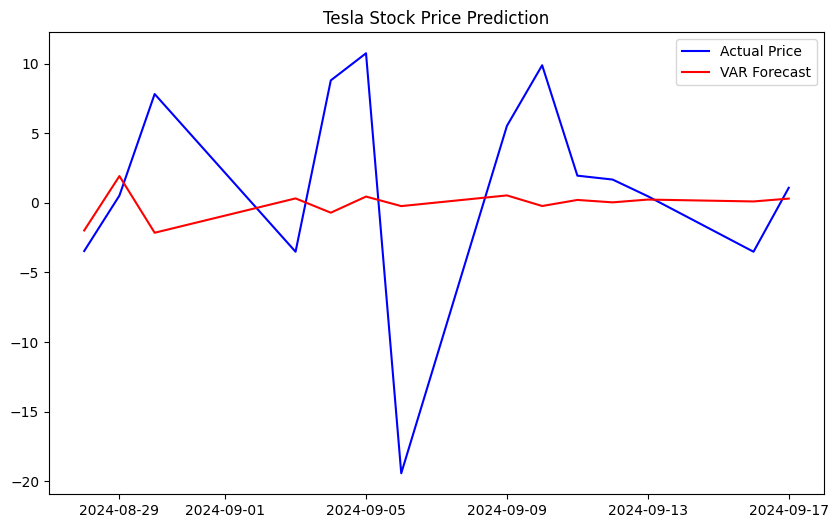

RMSE 7.7


In [42]:
from statsmodels.tsa.api import VAR, VARMAX
import pandas as pd
# VAR
model = VAR(train_data)
result = model.fit(maxlags=7)

predictions = result.forecast(train_data.values[-result.k_ar:], steps=len(test_data))

predictions =pd.DataFrame(predictions, index=test_data.index, columns=test_data.columns)

plt.figure(figsize=(10,6))
plt.plot(test_data.index, test_data['TSLA_Close'], label='Actual Price', color='blue')
plt.plot(test_data.index, predictions['TSLA_Close'], label='VAR Forecast', color='red')
plt.legend()
plt.title('Tesla Stock Price Prediction')
plt.show()

# evaluating model using RMSE score
rmse = round(np.sqrt(mean_squared_error(test_data['TSLA_Close'], predictions['TSLA_Close'])), 2)
print("RMSE", rmse)

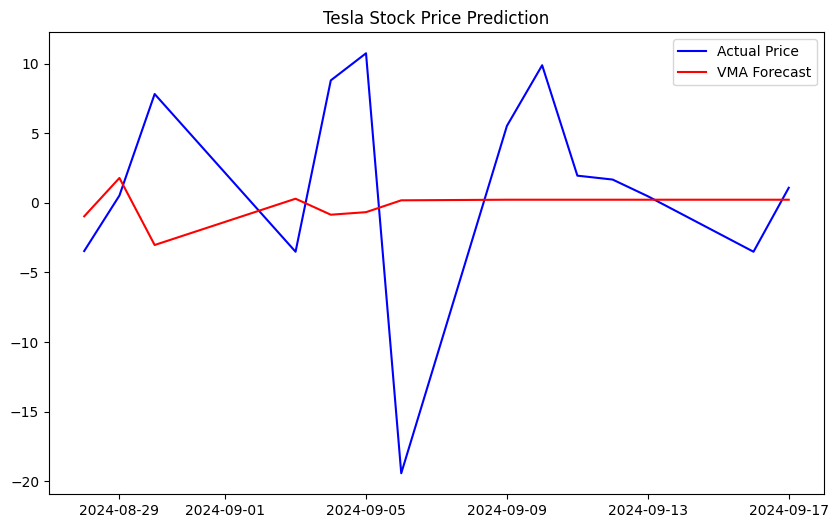

RMSE 7.98


In [43]:
# VMA
model = VARMAX(train_data, order=(0,7))
result = model.fit()

predictions = result.predict(
    start = len(train_data),
    end = len(train_data) + len(test_data) -1,
    dynamic=False
)


plt.figure(figsize=(10,6))
plt.plot(test_data.index, test_data['TSLA_Close'], label='Actual Price', color='blue')
plt.plot(test_data.index, predictions['TSLA_Close'], label='VMA Forecast', color='red')
plt.legend()
plt.title('Tesla Stock Price Prediction')
plt.show()

# evaluating model using RMSE score
rmse = round(np.sqrt(mean_squared_error(test_data['TSLA_Close'], predictions['TSLA_Close'])), 2)
print("RMSE", rmse)

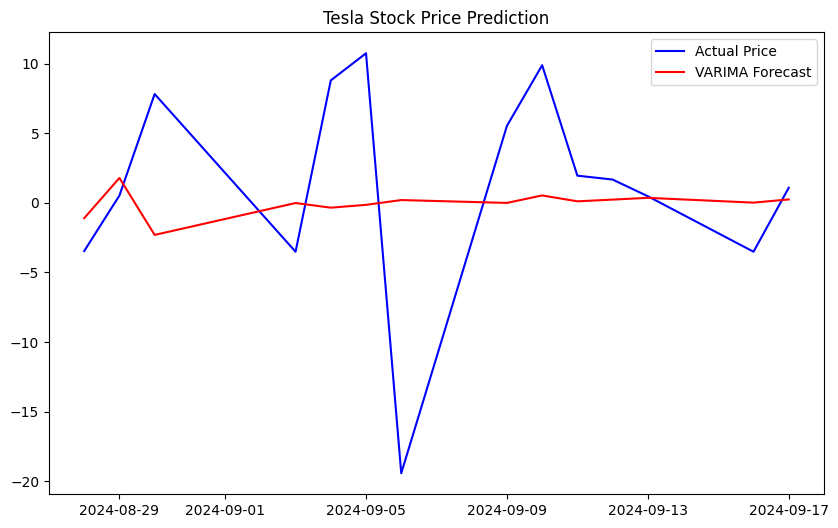

RMSE 7.78


In [44]:
# VARIMA
model = VARMAX(train_data, order=(7,7))
result = model.fit()

predictions = result.predict(
    start = len(train_data),
    end = len(train_data) + len(test_data) -1,
    dynamic=False
)


plt.figure(figsize=(10,6))
plt.plot(test_data.index, test_data['TSLA_Close'], label='Actual Price', color='blue')
plt.plot(test_data.index, predictions['TSLA_Close'], label='VARIMA Forecast', color='red')
plt.legend()
plt.title('Tesla Stock Price Prediction')
plt.show()

# evaluating model using RMSE score
rmse = round(np.sqrt(mean_squared_error(test_data['TSLA_Close'], predictions['TSLA_Close'])), 2)
print("RMSE", rmse)

### Smoothing Methods 

#### Moving Average

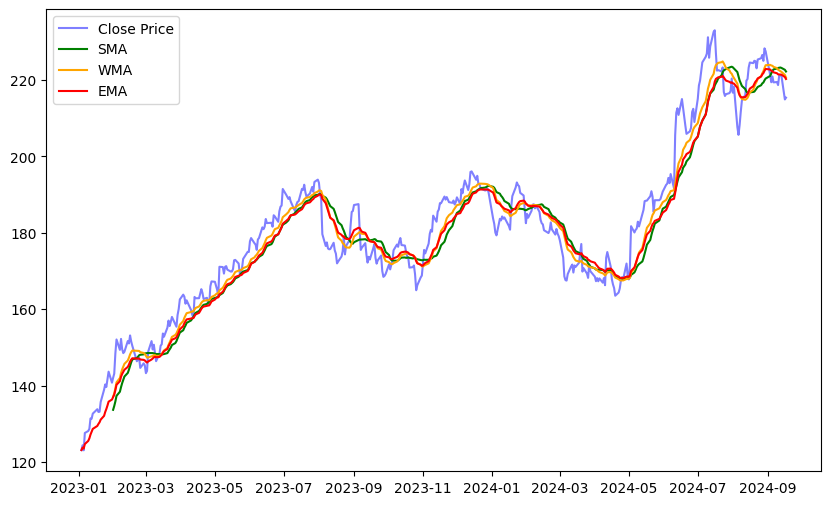

In [66]:
prices = stock_data['Close']['AAPL']
window_size = 20

stock_data['SMA'] = prices.rolling(window=window_size).mean()

weights = np.arange(1, window_size + 1)
stock_data['WMA'] = prices.rolling(window_size).apply(
    lambda x: np.dot(x, weights) / weights.sum(), raw=True
)

stock_data['EMA'] = prices.ewm(span=window_size).mean()
plt.figure(figsize=(10,6))

plt.plot(prices, label='Close Price', color='blue', alpha=0.5)
plt.plot(stock_data['SMA'], label='SMA', color='green')
plt.plot(stock_data['WMA'], label='WMA', color='orange')
plt.plot(stock_data['EMA'], label='EMA', color='red')

plt.legend()
plt.show()

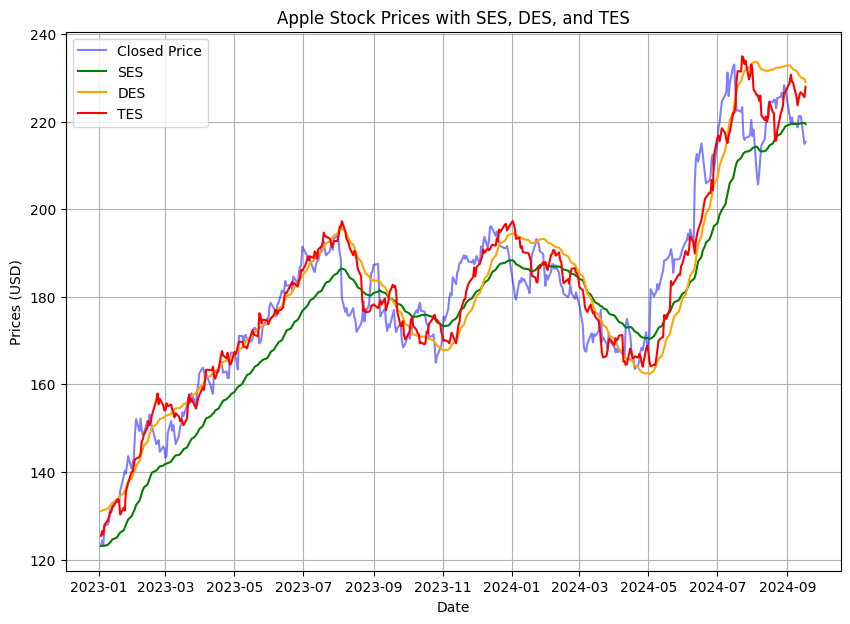

In [84]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

close_prices = prices
ses = SimpleExpSmoothing(close_prices).fit(smoothing_level=0.05)
stock_data['SES'] = ses.fittedvalues

# Double Exponential Smoothing - Holt's Linear trend model
des = ExponentialSmoothing(close_prices, trend='add').fit(smoothing_level=0.05)
stock_data['DES'] = des.fittedvalues

# Triple Exponential Smoothing - Holt's Winter Method
tes = ExponentialSmoothing(close_prices, trend='add', seasonal='add', seasonal_periods=12).fit(smoothing_level=0.05)
stock_data['TES'] = tes.fittedvalues

# Plotting
plt.figure(figsize=(10,7))
plt.plot(stock_data['Close'], label='Closed Price', color='blue', alpha=0.5)
plt.plot(stock_data['SES'], label='SES', color='green')
plt.plot(stock_data['DES'], label='DES', color='orange')
plt.plot(stock_data['TES'], label='TES', color='red')

plt.title("Apple Stock Prices with SES, DES, and TES")
plt.xlabel("Date")
plt.ylabel("Prices (USD)")
plt.legend()
plt.grid()
plt.show()

## ACF and PACF plots

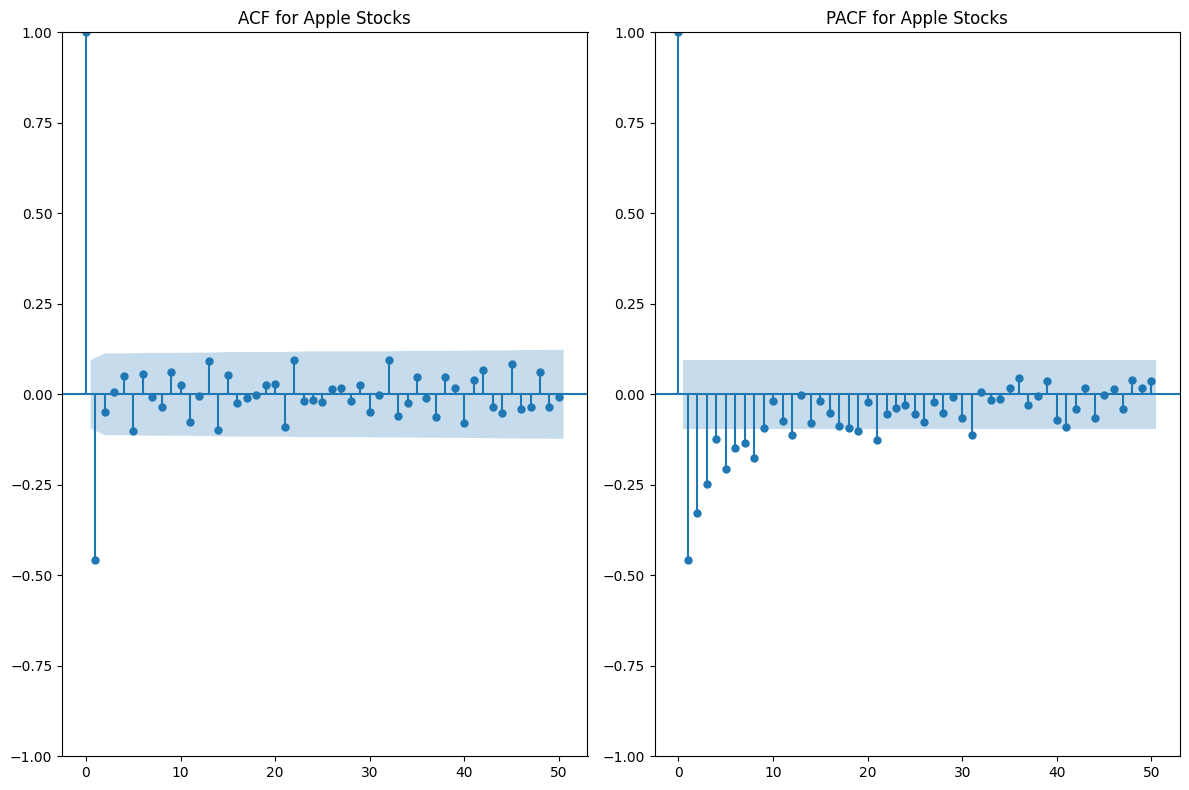

In [87]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.figure(figsize=(12,8))

# ACF Plots
plt.subplot(1, 2, 1)
plot_acf(stock_data['Close'].diff().diff().dropna(), ax=plt.gca(), lags=50)
plt.title("ACF for Apple Stocks")

# PACF Plots
plt.subplot(1, 2, 2)
plot_pacf(stock_data['Close'].diff().diff().dropna(), ax=plt.gca(), lags=50, method='ywm')
plt.title("PACF for Apple Stocks")

plt.tight_layout()
plt.show()

### Model Evaluation Metrics

In [89]:
train_data, test_data = apple_price_stationary[:-30], apple_price_stationary[-30:] 

# Fit the Auto Regressive model (AR) to the training
model = AutoReg(train_data, lags=30)
model_fit = model.fit()

# Make predictions on test data
predictions = model_fit.predict(
    start = len(train_data),
    end = len(train_data) + len(test_data) - 1,
    dynamic = False
)

In [100]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Mean Absolute Error
mae = mean_absolute_error(test_data, predictions)
print(f'Mean Absolute Error : {mae}')

# 2. Mean Squared Error
mse = mean_squared_error(test_data, predictions)
print(f'Mean Squared Error : {mse}')

# 3. Root Mean Squared Error
rmse = np.sqrt(mse)
print(f'Root Mean Squared Error : {rmse}')

# 4. Mean Absolute Percentage Error
mape = np.mean(np.abs((test_list - predictions) / test_list))*100
print(f'Mean Absolute Percentage Error : {mape}%')

# AIC and BIC
aic = model_fit.aic
bic = model_fit.bic

print(f'Akaike Information Criterion (AIC): {aic}')
print(f'Bayesian Information Criterion (BIC): {bic}')

Mean Absolute Error : 1.8889311994233928
Mean Squared Error : 5.859918988311074
Root Mean Squared Error : 2.420726954514093
Mean Absolute Percentage Error : 165.26016897270253%
Akaike Information Criterion (AIC): 1768.028408635316
Bayesian Information Criterion (BIC): 1893.0870626567219


In [102]:
model = AutoReg(train_data, lags=20)
model_fit = model.fit()

# Make predictions on test data
predictions = model_fit.predict(
    start = len(train_data),
    end = len(train_data) + len(test_data) - 1,
    dynamic = False
)
# 1. Mean Absolute Error
mae = mean_absolute_error(test_data, predictions)
print(f'Mean Absolute Error : {mae}')

# 2. Mean Squared Error
mse = mean_squared_error(test_data, predictions)
print(f'Mean Squared Error : {mse}')

# 3. Root Mean Squared Error
rmse = np.sqrt(mse)
print(f'Root Mean Squared Error : {rmse}')

# 4. Mean Absolute Percentage Error
mape = np.mean(np.abs((test_list - predictions) / test_list))*100
print(f'Mean Absolute Percentage Error : {mape}%')

# AIC and BIC
aic = model_fit.aic
bic = model_fit.bic

print(f'Akaike Information Criterion (AIC): {aic}')
print(f'Bayesian Information Criterion (BIC): {bic}')

Mean Absolute Error : 1.7020108837924055
Mean Squared Error : 5.336789163367402
Root Mean Squared Error : 2.3101491647440002
Mean Absolute Percentage Error : 117.26373323137034%
Akaike Information Criterion (AIC): 1803.899934171708
Bayesian Information Criterion (BIC): 1890.467606475339


In [107]:
data = {
'Date': ['2024-01-01', '2024-01-02', '2024-01-04', '2024-01-07', '2024-01-08', '2024-01-09', '2024-01-10', '2024-01-12'],
'Price': [100, 101, 103, 106, 107, 108, 109, 111]
}
#  Create a Dataframe
data = pd.DataFrame(data)
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)
data

,Price
Date,
2024-01-01,100
2024-01-02,101
2024-01-04,103
2024-01-07,106
2024-01-08,107
2024-01-09,108
2024-01-10,109
2024-01-12,111


In [108]:
# Create a complete data range
complete_index = pd.date_range(start='2024-01-01', end='2024-01-12', freq='D')
# Reindex the dataframe
data = data.reindex(complete_index)

print("Reindexed Dataframe with Missing Dates:\n", data)

Reindexed Dataframe with Missing Dates:
             Price
2024-01-01  100.0
2024-01-02  101.0
2024-01-03    NaN
2024-01-04  103.0
2024-01-05    NaN
2024-01-06    NaN
2024-01-07  106.0
2024-01-08  107.0
2024-01-09  108.0
2024-01-10  109.0
2024-01-11    NaN
2024-01-12  111.0


### 1. Imputation

In [111]:
# Mean Imputation
mean_value = data.mean()
data_mean_imputated = data.fillna(mean_value)
# Median Imputation
median_value = data.median()
data_median_imputated = data.fillna(median_value)
# Mode Imputation
mode_value = data.mode()
data_mode_imputated = data.fillna(mode_value.values[0][0])

# Forward fill
data_ffill = data.ffill()

# Backward fill
data_bfill = data.bfill()

print("Original Dataset\n", data)
print("----------------\nMean", mean_value.values[0])
print("----------------\nMean Imputation :", data_mean_imputated)
print("----------------\nMedian", median_value.values[0])
print("----------------\nMedian Imputation :", data_median_imputated)
print("----------------\nMode", mode_value.values[0])
print("----------------\nMode Imputation :", data_mode_imputated)
print("----------------\nForward Fill :\n",data_ffill)
print("----------------\nBackward Fill :\n", data_bfill)


Original Dataset
             Price
2024-01-01  100.0
2024-01-02  101.0
2024-01-03    NaN
2024-01-04  103.0
2024-01-05    NaN
2024-01-06    NaN
2024-01-07  106.0
2024-01-08  107.0
2024-01-09  108.0
2024-01-10  109.0
2024-01-11    NaN
2024-01-12  111.0
----------------
Mean 105.625
----------------
Mean Imputation :               Price
2024-01-01  100.000
2024-01-02  101.000
2024-01-03  105.625
2024-01-04  103.000
2024-01-05  105.625
2024-01-06  105.625
2024-01-07  106.000
2024-01-08  107.000
2024-01-09  108.000
2024-01-10  109.000
2024-01-11  105.625
2024-01-12  111.000
----------------
Median 106.5
----------------
Median Imputation :             Price
2024-01-01  100.0
2024-01-02  101.0
2024-01-03  106.5
2024-01-04  103.0
2024-01-05  106.5
2024-01-06  106.5
2024-01-07  106.0
2024-01-08  107.0
2024-01-09  108.0
2024-01-10  109.0
2024-01-11  106.5
2024-01-12  111.0
----------------
Mode [100.]
----------------
Mode Imputation :             Price
2024-01-01  100.0
2024-01-02  101.0
2024

### Interpolation

In [114]:
# Linear Interpolation
data_linear_inter = data.interpolate(method='linear')
# Polynomial Interpolation
data_polynomial_inter = data.interpolate(method='polynomial', order=2)
# Spline Interpolation
data_spline_inter = data.interpolate(method='spline', order=2)

print("\nLinear Interpolation:\n", data_linear_inter)
print("\nPolynomial Interpolation (degree 2):\n", data_polynomial_inter)
print("\nSpline Interpolation (order 2):\n", data_spline_inter)


Linear Interpolation:
             Price
2024-01-01  100.0
2024-01-02  101.0
2024-01-03  102.0
2024-01-04  103.0
2024-01-05  104.0
2024-01-06  105.0
2024-01-07  106.0
2024-01-08  107.0
2024-01-09  108.0
2024-01-10  109.0
2024-01-11  110.0
2024-01-12  111.0

Polynomial Interpolation (degree 2):
             Price
2024-01-01  100.0
2024-01-02  101.0
2024-01-03  102.0
2024-01-04  103.0
2024-01-05  104.0
2024-01-06  105.0
2024-01-07  106.0
2024-01-08  107.0
2024-01-09  108.0
2024-01-10  109.0
2024-01-11  110.0
2024-01-12  111.0

Spline Interpolation (order 2):
             Price
2024-01-01  100.0
2024-01-02  101.0
2024-01-03  102.0
2024-01-04  103.0
2024-01-05  104.0
2024-01-06  105.0
2024-01-07  106.0
2024-01-08  107.0
2024-01-09  108.0
2024-01-10  109.0
2024-01-11  110.0
2024-01-12  111.0


### Predictive Modelling

In [120]:
data['Sales'] = [700,900,1000,2000,1500, 3000, 2300,4000, 5900, 6000, 65000, 7000]
data

,Price,Sales
2024-01-01,100.0,700
2024-01-02,101.0,900
2024-01-03,NaN,1000
2024-01-04,103.0,2000
2024-01-05,NaN,1500
2024-01-06,NaN,3000
2024-01-07,106.0,2300
2024-01-08,107.0,4000
2024-01-09,108.0,5900
2024-01-10,109.0,6000


In [121]:
from sklearn. linear_model import LinearRegression

known_data = data.dropna(subset=['Price'])
missing_data = data[data['Price'].isna()]

# Train a model on known data
model = LinearRegression()
model.fit(known_data[['Sales']], known_data['Price'])

# Predict missing values
predicted_values = model.predict(missing_data[['Sales']])
data.loc[data['Price'].isna(), 'Price'] = predicted_values

print("\nData with Predicted Values:\n", data)


Data with Predicted Values:
                  Price  Sales
2024-01-01  100.000000    700
2024-01-02  101.000000    900
2024-01-03  101.675094   1000
2024-01-04  103.000000   2000
2024-01-05  102.434691   1500
2024-01-06  104.713483   3000
2024-01-07  106.000000   2300
2024-01-08  107.000000   4000
2024-01-09  108.000000   5900
2024-01-10  109.000000   6000
2024-01-11  198.903558  65000
2024-01-12  111.000000   7000


### Resampling

In [122]:
monthly_data = stock['Close'].resample('M').mean()
print("\nMonthly Downsampled Data:\n", monthly_data)


Monthly Downsampled Data:
 Ticker            AAPL
Date                  
2023-01-31  134.190739
2023-02-28  148.728724
2023-03-31  152.751844
2023-04-30  162.688898
2023-05-31  170.297711
2023-06-30  181.902977
2023-07-31  189.926161
2023-08-31  178.900712
2023-09-30  174.952128
2023-10-31  172.645296
2023-11-30  183.890571
2023-12-31  192.310686
2024-01-31  185.794162
2024-02-29  183.037856
2024-03-31  171.138993
2024-04-30  168.074920
2024-05-31  184.779420
2024-06-30  204.680157
2024-07-31  222.874921
2024-08-31  220.113756
2024-09-30  219.366282


### Upsampling

In [123]:
hourly_data = stock_data['Close'].resample('H').interpolate(method='linear')
print("\nHourly Upsampled Data:\n", hourly_data)


Hourly Upsampled Data:
 Ticker                     AAPL
Date                           
2023-01-03 00:00:00  123.096016
2023-01-03 01:00:00  123.148918
2023-01-03 02:00:00  123.201820
2023-01-03 03:00:00  123.254723
2023-01-03 04:00:00  123.307625
...                         ...
2024-09-16 20:00:00  215.297407
2024-09-16 21:00:00  215.316862
2024-09-16 22:00:00  215.336318
2024-09-16 23:00:00  215.355773
2024-09-17 00:00:00  215.375229

[14953 rows x 1 columns]
